In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Task
Perform an exploratory data analysis (EDA) on the image dataset. This includes: summarizing descriptive statistics for image properties (height, width, channels, min_pixel, max_pixel, mean_pixel, std_pixel) from `image_df`; analyzing and visualizing the distribution of image sources ('palsar', 'sentinel') from the 'filename' column in `image_df`; reporting on identified data quality issues such as dimension mismatches, corrupted files, and empty masks using the `problems` dictionary and related lists; visualizing the distributions of `min_pixel`, `max_pixel`, `mean_pixel`, and `std_pixel` values from `image_df`; visualizing the `height` and `width` distributions of images from `image_df`; and displaying a few sample paired satellite images and their corresponding mask images from the `paired_images` list. Finally, summarize the key findings from this EDA, including insights into image characteristics, data quality, and any observed patterns or anomalies.

## Summarize Image Properties

### Subtask:
Display descriptive statistics for numerical columns in the 'image_df' such as height, width, channels, min_pixel, max_pixel, mean_pixel, and std_pixel to understand the overall characteristics of the images.


**Reasoning**:
To understand the overall characteristics of the images, I will display descriptive statistics for numerical columns in the 'image_df' DataFrame using the `.describe()` method as instructed.



In [ ]:
image_df.describe()

,height,width,channels,min_pixel,max_pixel,mean_pixel,std_pixel
count,500.0,500.0,500.0,500.000000,500.000000,500.000000,500.000000
mean,256.0,256.0,1.0,6.200000,230.916000,109.147284,40.013896
std,0.0,0.0,0.0,12.584464,41.507815,33.073472,14.848685
min,256.0,256.0,1.0,0.000000,56.000000,23.697998,5.462749
25%,256.0,256.0,1.0,0.000000,223.000000,84.738060,28.734591
50%,256.0,256.0,1.0,0.000000,255.000000,112.960136,42.997176
75%,256.0,256.0,1.0,7.000000,255.000000,134.159328,51.997541
max,256.0,256.0,1.0,92.000000,255.000000,175.383133,73.831445


## Analyze Image Sources

### Subtask:
Extract and count the occurrences of different image sources (e.g., 'palsar', 'sentinel') from the 'filename' column in 'image_df' and visualize their distribution using a bar chart.


**Reasoning**:
To analyze the distribution of image sources, I will extract the source type (palsar or sentinel) from the 'filename' column in 'image_df' and then count the occurrences of each source. The filename column contains paths like 'train/palsar_2049.png', so splitting by '/' and then '_' should give the source.



In [ ]:
image_df['source'] = image_df['filename'].apply(lambda x: x.split('/')[1].split('_')[0])
source_counts = image_df['source'].value_counts()
print("Image Source Distribution:")
print(source_counts)

Image Source Distribution:
source
sentinel    268
palsar      232
Name: count, dtype: int64


**Reasoning**:
To visualize the distribution of image sources, I will use `seaborn.barplot` with the `source_counts` obtained previously, and then set the plot title and axis labels using `matplotlib.pyplot`.



/tmp/ipython-input-182132447.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_counts.index, y=source_counts.values, palette='viridis')


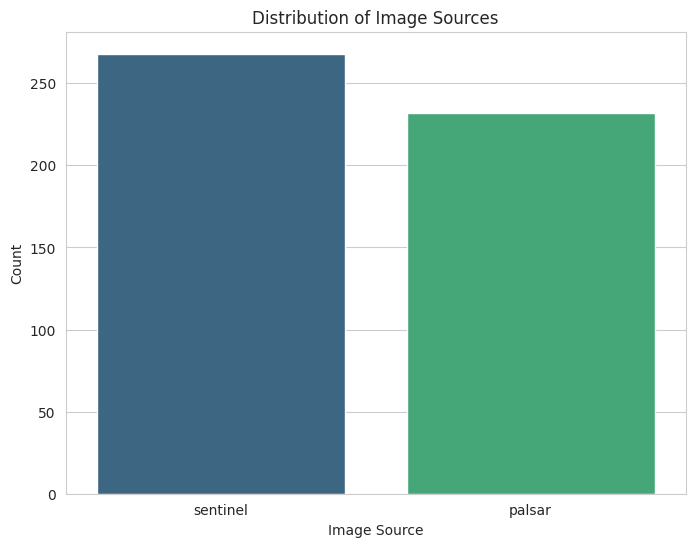

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x=source_counts.index, y=source_counts.values, palette='viridis')
plt.title('Distribution of Image Sources')
plt.xlabel('Image Source')
plt.ylabel('Count')
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` from seaborn regarding the use of `palette` without `hue`. To address this, I will explicitly assign the `x` variable to `hue` and set `legend=False` as suggested by the warning.



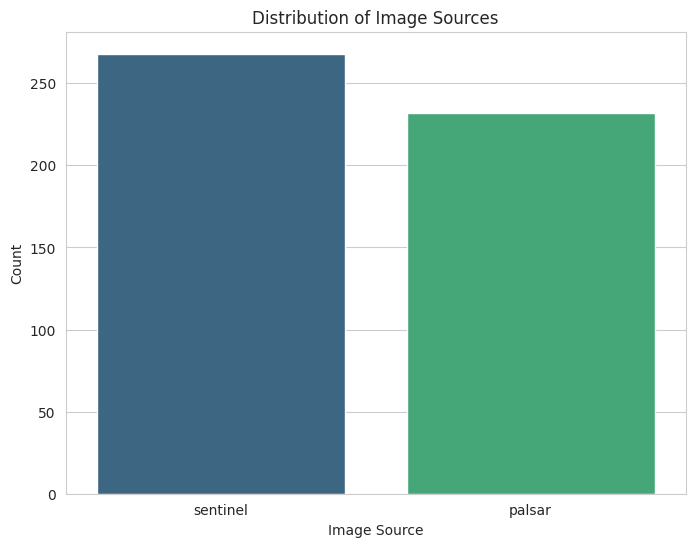

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x=source_counts.index, y=source_counts.values, hue=source_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Image Sources')
plt.xlabel('Image Source')
plt.ylabel('Count')
plt.show()

## Report Data Quality Issues

### Subtask:
Summarize the counts of identified data quality issues such as dimension mismatches, corrupted files, and empty masks, using the 'problems' dictionary and other relevant lists ('dimension_mismatches', 'corrupt_files', 'empty_masks') from the kernel state.


**Reasoning**:
To summarize the data quality issues, I will print the counts from the 'problems' dictionary for dimension mismatches, corrupted pairs, and empty masks, and also print the lengths of the corresponding lists ('dimension_mismatches', 'corrupt_files', and 'empty_masks') to provide detailed counts.



In [ ]:
print("--- Data Quality Issue Summary ---")
print(f"Dimension Mismatches (from problems dict): {problems['dimension_mismatch']}")
print(f"Corrupted Files (from problems dict): {problems['corrupted_pairs']}")
print(f"Empty Masks (from problems dict): {problems['empty_masks']}")
print(f"Number of files with dimension mismatches: {len(dimension_mismatches)}")
print(f"Number of corrupted files: {len(corrupt_files)}")
print(f"Number of empty masks: {len(empty_masks)}")

--- Data Quality Issue Summary ---
Dimension Mismatches (from problems dict): 0
Corrupted Files (from problems dict): 0
Empty Masks (from problems dict): 0
Number of files with dimension mismatches: 0
Number of corrupted files: 0
Number of empty masks: 0


## Visualize Pixel Value Distributions

### Subtask:
Generate histograms for 'min_pixel', 'max_pixel', 'mean_pixel', and 'std_pixel' from 'image_df' to visualize the distribution of pixel intensity statistics across the dataset.


**Reasoning**:
To visualize the distribution of pixel intensity statistics, I will generate histograms for 'min_pixel', 'max_pixel', 'mean_pixel', and 'std_pixel' from 'image_df' using seaborn and matplotlib.



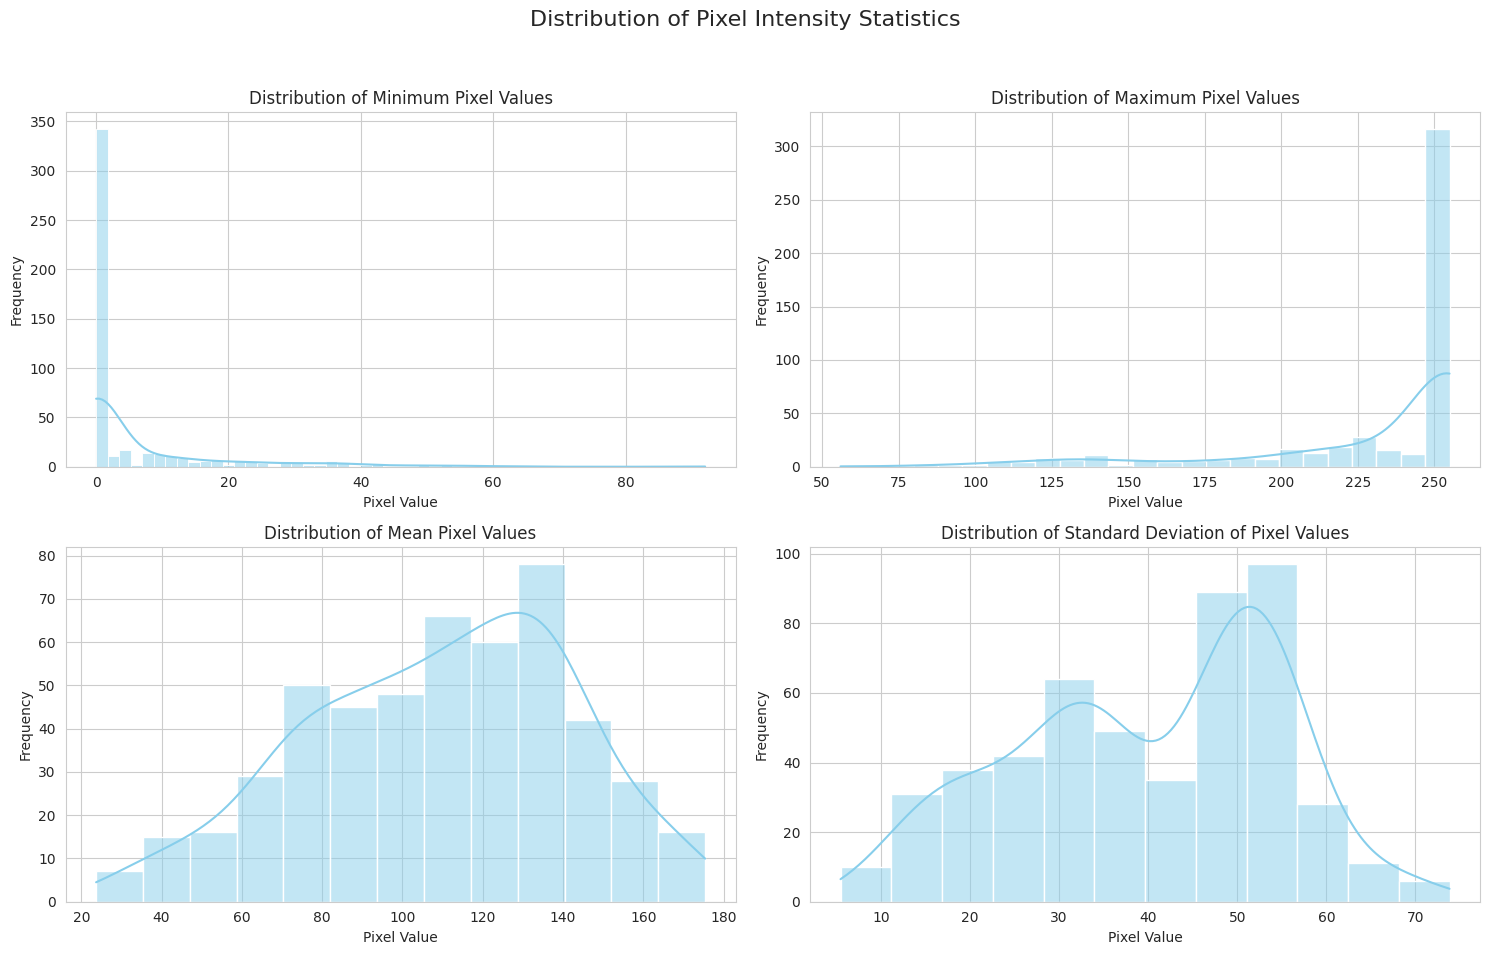

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
fig.suptitle('Distribution of Pixel Intensity Statistics', fontsize=16)

# List of columns to plot
pixel_columns = ['min_pixel', 'max_pixel', 'mean_pixel', 'std_pixel']

# Titles for the subplots
pixel_titles = [
    'Distribution of Minimum Pixel Values',
    'Distribution of Maximum Pixel Values',
    'Distribution of Mean Pixel Values',
    'Distribution of Standard Deviation of Pixel Values'
]

for i, col in enumerate(pixel_columns):
    row = i // 2
    col_idx = i % 2
    sns.histplot(image_df[col], kde=True, ax=axes[row, col_idx], color='skyblue')
    axes[row, col_idx].set_title(pixel_titles[i])
    axes[row, col_idx].set_xlabel('Pixel Value')
    axes[row, col_idx].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Reasoning**:
To visualize the distribution of image dimensions, I will generate histograms for 'height' and 'width' from 'image_df' using seaborn and matplotlib.



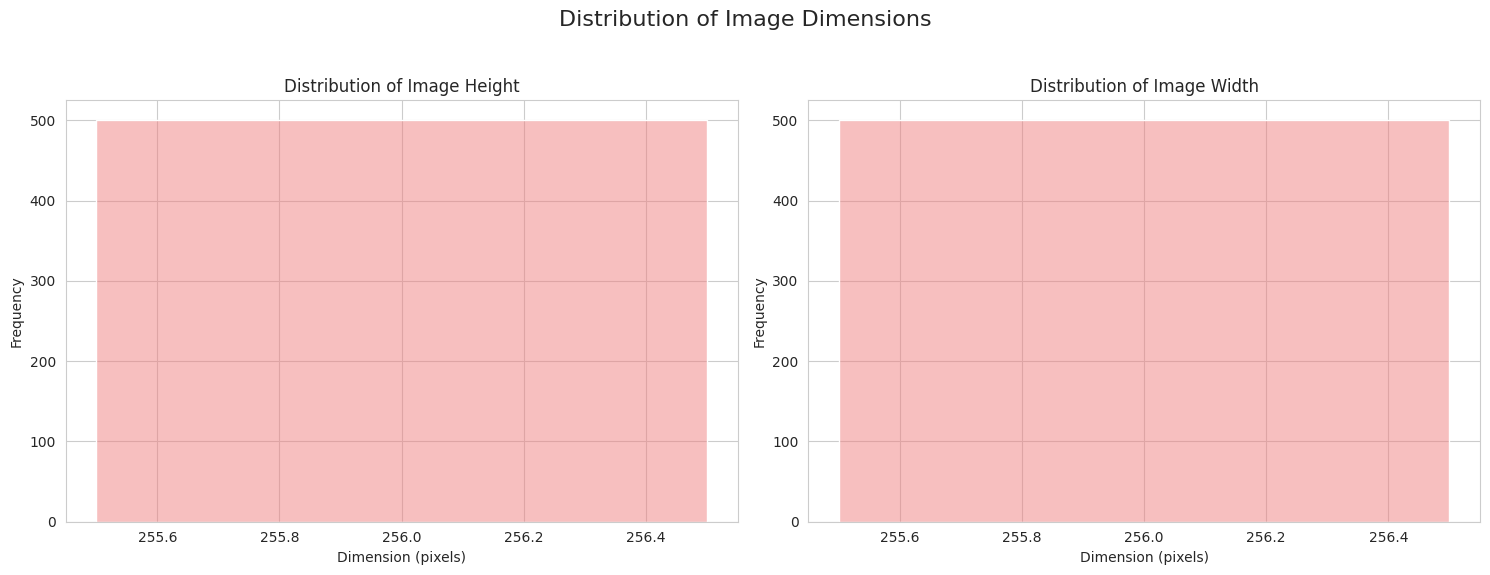

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
fig.suptitle('Distribution of Image Dimensions', fontsize=16)

# List of columns to plot
dimension_columns = ['height', 'width']

# Titles for the subplots
dimension_titles = [
    'Distribution of Image Height',
    'Distribution of Image Width'
]

for i, col in enumerate(dimension_columns):
    sns.histplot(image_df[col], kde=True, ax=axes[i], color='lightcoral')
    axes[i].set_title(dimension_titles[i])
    axes[i].set_xlabel('Dimension (pixels)')
    axes[i].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Display Sample Image-Mask Pairs

### Subtask:
Select and display a few sample paired satellite images and their corresponding mask images to provide a visual understanding of the data content and pairing.


**Reasoning**:
To visually understand the data content and pairing, I will import necessary libraries, select a few sample image-mask pairs from the `paired_images` list, and then iterate through them to display each satellite image alongside its corresponding mask using subplots, ensuring proper titles and layout.



Displaying 3 sample paired satellite and mask images...


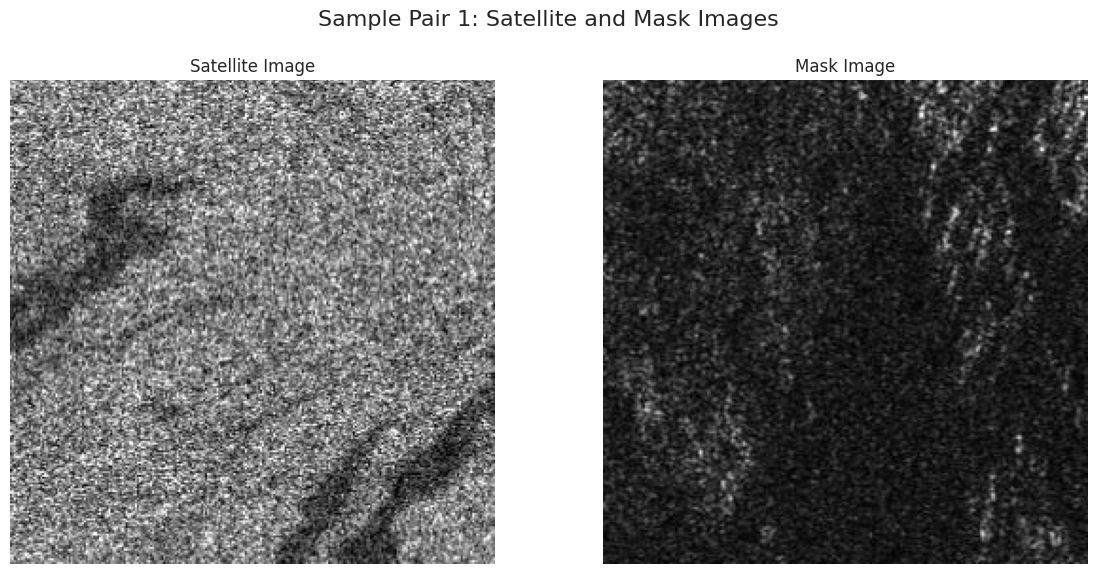

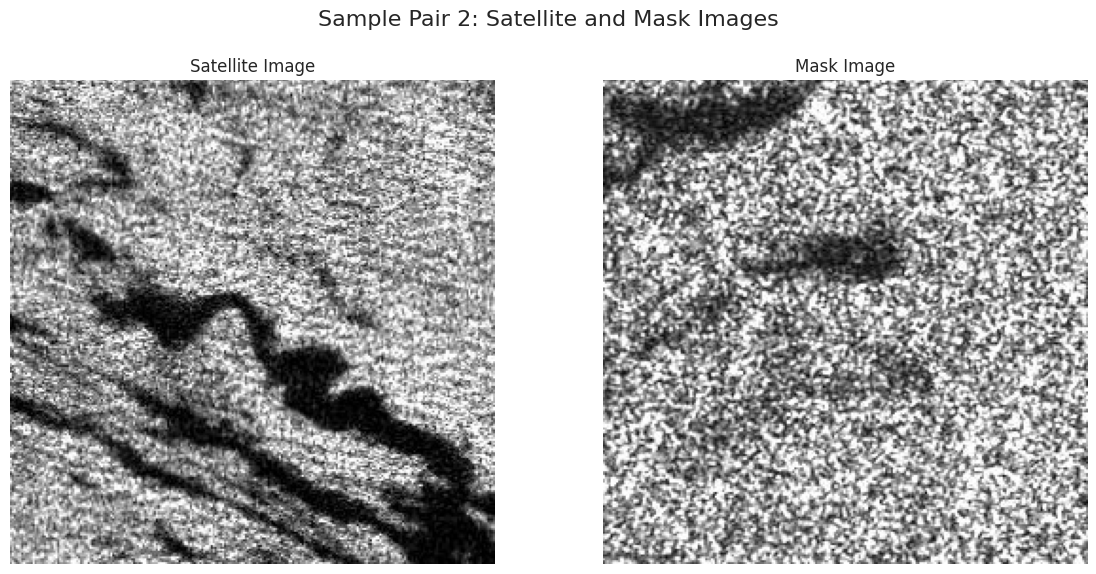

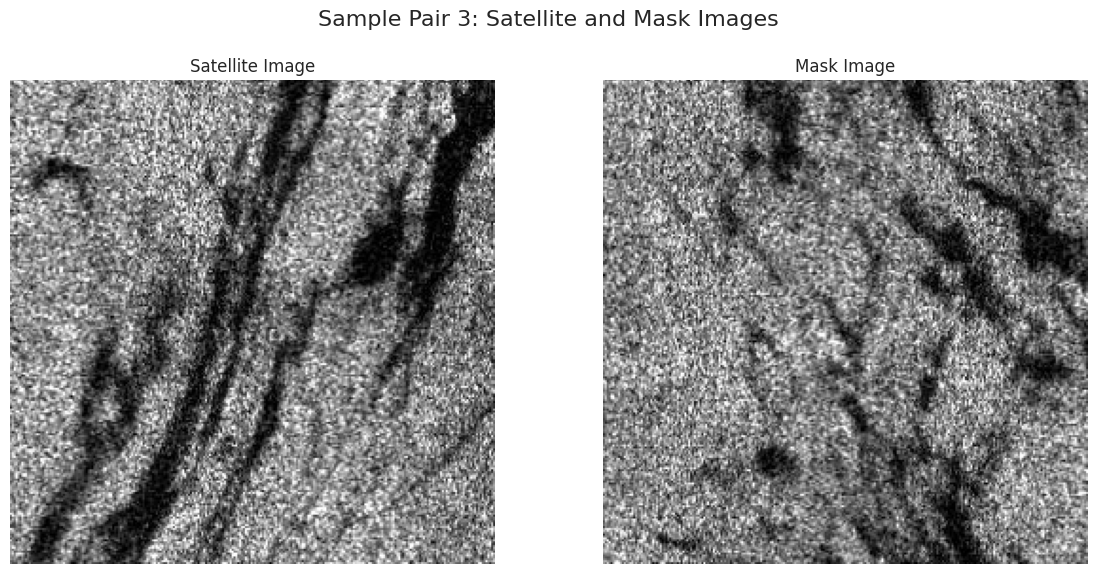

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Select a small number of sample pairs to display
num_samples = 3
sample_pairs = paired_images[:num_samples]

print(f"Displaying {num_samples} sample paired satellite and mask images...")

for i, (sat_path, mask_path) in enumerate(sample_pairs):
    # Open the images
    sat_image = Image.open(sat_path)
    mask_image = Image.open(mask_path)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f'Sample Pair {i+1}: Satellite and Mask Images', fontsize=16)

    # Display satellite image
    axes[0].imshow(sat_image)
    axes[0].set_title('Satellite Image')
    axes[0].axis('off')

    # Display mask image
    axes[1].imshow(mask_image)
    axes[1].set_title('Mask Image')
    axes[1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Final Task

### Subtask:
Summarize the key findings from the EDA, including insights into image characteristics, data quality, and any observed patterns or anomalies.


## Summary:

### Data Analysis Key Findings

*   **Image Dimensions and Channels:** All 500 images in the dataset are consistently sized at 256x256 pixels and have 1 channel, indicating they are grayscale images.
*   **Pixel Intensity Range:**
    *   `min_pixel` values range from 0 to 92, with an average of 6.2, suggesting some images contain pure black pixels while others have a non-zero minimum intensity.
    *   `max_pixel` values range from 56 to 255, with an average of 230.91. Many images reach the maximum intensity of 255, but some have a considerably lower maximum.
*   **Overall Brightness and Contrast:**
    *   `mean_pixel` values vary widely from 23.69 to 175.38, with an average of 109.14, indicating diverse overall brightness levels across the images.
    *   `std_pixel` values (a measure of contrast) range from 5.46 to 73.83, with an average of 40.01, showing varying levels of texture or contrast within the images.
*   **Image Source Distribution:** The dataset comprises two main image sources: 'sentinel' (268 images) and 'palsar' (232 images), indicating a fairly balanced distribution between the two.
*   **Data Quality:** No data quality issues were identified regarding dimension mismatches, corrupted files, or empty masks. This suggests a clean and well-prepared dataset in these aspects.
*   **Pixel Value Distribution Shapes:** Histograms revealed diverse distributions for pixel statistics, particularly for `mean_pixel` and `std_pixel`, which are spread across a wide range, further confirming the variability in image brightness and contrast.
*   **Sample Image Pairs:** Visual inspection of sample satellite and mask image pairs confirmed the successful pairing and provided a clear understanding of the visual content and the nature of the mask data.

### Insights or Next Steps

*   The variability in `min_pixel`, `max_pixel`, `mean_pixel`, and `std_pixel` values suggests a need for potential pixel intensity normalization or standardization during model training to ensure consistent input characteristics.
*   The balanced distribution of 'sentinel' and 'palsar' sources is beneficial for training robust models, but further analysis could explore if specific pixel value characteristics correlate with image source or if the model should handle them differently.
